# Zenodo Dataset — Graph Construction & Data Characterisation

**Dataset:** KU Leuven Blackboard LMS (Tiukhova et al., 2024)  
**Zenodo record:** [17087849](https://zenodo.org/records/17087849)  
**Pipeline version:** `v2_corrected`  
**Prediction window:** Week 8 (56 days from course start)

This notebook mirrors the structure of `OULAD_Graph_Analysis_Final.ipynb` for the
external Zenodo dataset. It covers data loading, graph construction, integrity validation,
split characterisation, and a side-by-side comparison with the OULAD graph.

> **Data note:** `data/Zenodo/dataset.zip` is gitignored (third-party data).  
> Artefacts in `results/zenodo/` are committed and can be loaded without the raw data.


## 0. Setup

In [1]:
import sys
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
warnings.filterwarnings("ignore")

# Resolve project root whether running from notebooks/ or project root
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

ZENODO_DIR   = PROJECT_ROOT / "results" / "zenodo"
ARTIFACTS    = ZENODO_DIR / "artifacts"
SPLITS_DIR   = ZENODO_DIR / "evaluation" / "week08" / "splits"
GRAPH_FIGS   = PROJECT_ROOT / "results" / "graph" / "figures"

sns.set_theme(style="whitegrid")
ATRISK  = "#e74c3c"
SUCCESS = "#3b82d4"
ACCENT  = "#7c5cd8"

print("Project root:", PROJECT_ROOT)
print("Zenodo artefacts:", ARTIFACTS)


Project root: /Users/olivialoza/Documents/Development/OULAD
Zenodo artefacts: /Users/olivialoza/Documents/Development/OULAD/results/zenodo/artifacts


## 1. Dataset Overview

The Zenodo dataset contains Blackboard LMS activity logs for **2 courses**
(*Accountancy*, *Global economics*) across **3 academic years** (2018–19, 2019–20,
2020–21) from KU Leuven. It was released alongside Tiukhova et al. (2024) as a
comparable but independently-collected dataset to OULAD.

### Schema gaps vs. OULAD

| OULAD feature | Zenodo equivalent | Status |
|---|---|---|
| `studentAssessment` | — | **GAP: absent** — no submitted/contains_assess edges |
| Student demographics | — | **GAP: absent** — no gender, age_band, imd_band, disability |
| Pre-computed day offsets | Calendar datetimes | Computed from `course_info.json` start dates |
| `studentVle` (click logs) | `log_activity` (action logs) | ✓ mapped — 1 action ≈ 1 click |
| `courseVle` | `course_content` | ✓ mapped |
| `studentRegistration` | `course_participation` | ✓ mapped (outcome = PASSED flag) |


In [2]:
# Load graph metadata written by materialize_zenodo_artifacts()
with open(ARTIFACTS / "week08_metadata.json") as f:
    meta = json.load(f)

print("=== Zenodo graph metadata (Week 8, 56-day window) ===")
for k, v in meta.items():
    print(f"  {k:30s}: {v}")


=== Zenodo graph metadata (Week 8, 56-day window) ===
  dataset                       : zenodo_17087849
  institution                   : KU Leuven (Tiukhova et al., 2024)
  week                          : 8
  window_days                   : 56
  supervised_unit               : enrollment (id_student, code_module, code_presentation)
  label_definition              : PASSED==0 → at-risk (target=1); PASSED==1 → success (target=0)
  gaps                          : ['No assessment nodes or submitted/contains_assess edges', 'No student demographic features', 'Timestamps are calendar datetimes (not pre-computed day offsets)']
  node_counts                   : {'student': 940, 'course_presentation': 6, 'vle_resource': 1138}
  edge_counts                   : {'enrolled_in': 4280, 'has_resource': 2172, 'interacted_with': 278207}
  enrollment_count              : 4280
  label_at_risk_count           : 1450
  label_success_count           : 2830
  label_at_risk_rate            : 0.3388
  elapsed_

In [3]:
# Load node and edge tables from artefacts
nodes = {}
edges = {}
for p in sorted(ARTIFACTS.glob("week08_nodes_*.parquet")):
    ntype = p.stem.replace("week08_nodes_", "")
    nodes[ntype] = pd.read_parquet(p)

for p in sorted(ARTIFACTS.glob("week08_edges_*.parquet")):
    etype = p.stem.replace("week08_edges_", "")
    edges[etype] = pd.read_parquet(p)

enrollments = pd.read_parquet(ARTIFACTS / "week08_enrollments.parquet")

print("=== Node counts ===")
for ntype, df in nodes.items():
    print(f"  {ntype:30s}: {len(df):>6,}")
print()
print("=== Edge counts ===")
for etype, df in edges.items():
    print(f"  {etype:30s}: {len(df):>8,}")
print()
print(f"  {'enrollments':30s}: {len(enrollments):>6,}")
print(f"  at-risk rate            : {enrollments['target'].mean():.1%}")


=== Node counts ===
  course_presentation           :      6
  student                       :    940
  vle_resource                  :  1,138

=== Edge counts ===
  enrolled_in                   :    4,280
  has_resource                  :    2,172
  interacted_with               :  278,207

  enrollments                   :  4,280
  at-risk rate            : 33.9%


## 2. Label Distribution by Course-Presentation

In [4]:
label_dist = (
    enrollments.groupby(["code_module", "code_presentation"])["target"]
    .agg(total="count", at_risk="sum")
    .assign(at_risk_rate=lambda d: (d["at_risk"] / d["total"]).round(3))
    .reset_index()
    .sort_values("at_risk_rate")
)
print("Label distribution per course-presentation:")
display(label_dist)


Label distribution per course-presentation:


,code_module,code_presentation,total,at_risk,at_risk_rate
4,Global economics,1920,681,167,0.245
0,Accountancy,1819,752,224,0.298
2,Accountancy,2021,723,216,0.299
1,Accountancy,1920,705,224,0.318
5,Global economics,2021,676,294,0.435
3,Global economics,1819,743,325,0.437


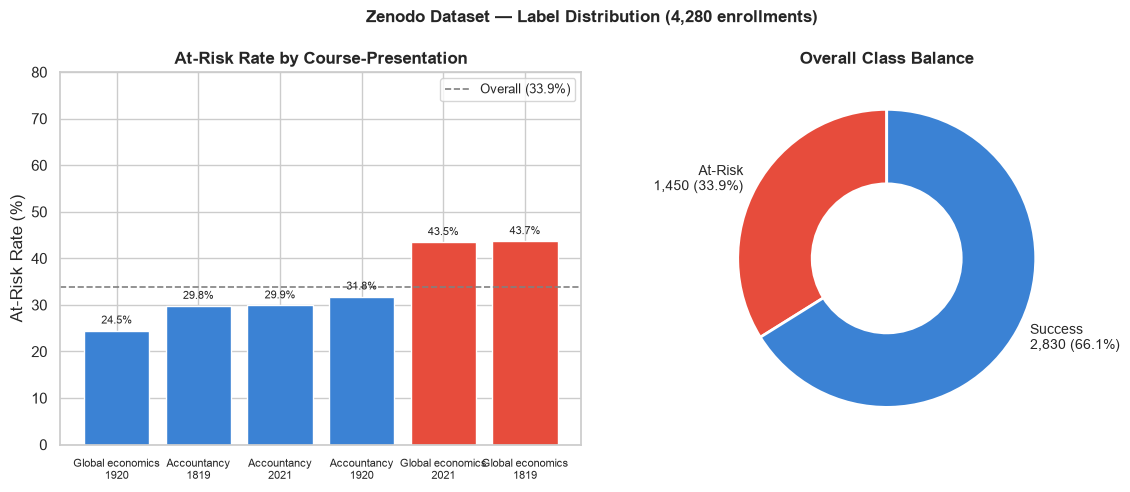

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Per-course bar
ax = axes[0]
labels_cp = label_dist["code_module"] + "\n" + label_dist["code_presentation"]
colors = [ATRISK if r >= 0.338 else SUCCESS for r in label_dist["at_risk_rate"]]
bars = ax.bar(labels_cp, label_dist["at_risk_rate"] * 100, color=colors, edgecolor="white")
ax.axhline(enrollments["target"].mean() * 100, color="grey", lw=1.2,
           linestyle="--", label=f"Overall ({enrollments['target'].mean():.1%})")
ax.set_ylabel("At-Risk Rate (%)")
ax.set_title("At-Risk Rate by Course-Presentation", fontweight="bold")
ax.set_ylim(0, 80)
ax.tick_params(axis="x", labelsize=8)
ax.legend(fontsize=9)
for bar, rate in zip(bars, label_dist["at_risk_rate"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"{rate:.1%}", ha="center", va="bottom", fontsize=8)

# Overall donut
ax = axes[1]
at_risk_n = int((enrollments["target"] == 1).sum())
success_n = int((enrollments["target"] == 0).sum())
wedge_props = dict(width=0.5, edgecolor="white", linewidth=2)
ax.pie([at_risk_n, success_n], colors=[ATRISK, SUCCESS],
       labels=[f"At-Risk\n{at_risk_n:,} ({at_risk_n/len(enrollments):.1%})",
               f"Success\n{success_n:,} ({success_n/len(enrollments):.1%})"],
       wedgeprops=wedge_props, startangle=90, textprops={"fontsize": 10})
ax.set_title("Overall Class Balance", fontweight="bold")

plt.suptitle("Zenodo Dataset — Label Distribution (4,280 enrollments)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


## 3. Graph Scale — Node and Edge Counts

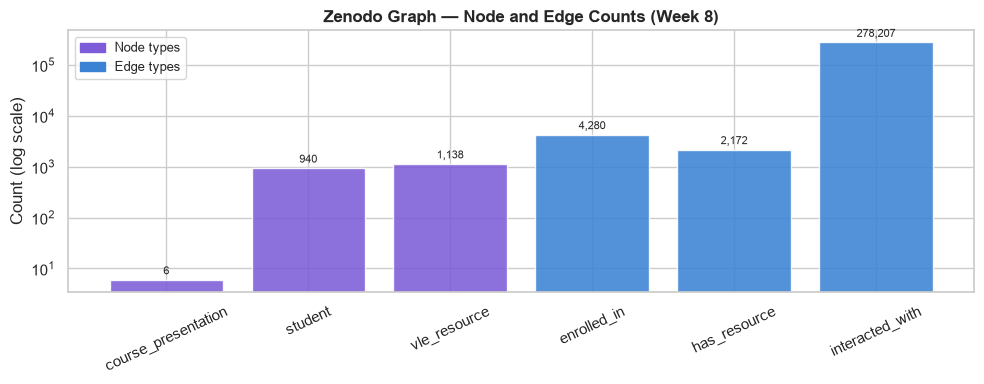

In [6]:
node_counts = {nt: len(df) for nt, df in nodes.items()}
edge_counts = {et: len(df) for et, df in edges.items()}

all_labels = list(node_counts.keys()) + list(edge_counts.keys())
all_values = list(node_counts.values()) + list(edge_counts.values())
all_colors = [ACCENT] * len(node_counts) + [SUCCESS] * len(edge_counts)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(all_labels, all_values, color=all_colors, edgecolor="white", alpha=0.88)
ax.set_ylabel("Count (log scale)")
ax.set_yscale("log")
ax.set_title("Zenodo Graph — Node and Edge Counts (Week 8)", fontweight="bold")
ax.tick_params(axis="x", rotation=25)
for bar, val in zip(bars, all_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.15,
            f"{val:,}", ha="center", va="bottom", fontsize=8)

import matplotlib.patches as mpatches
ax.legend(handles=[mpatches.Patch(color=ACCENT, label="Node types"),
                   mpatches.Patch(color=SUCCESS, label="Edge types")], fontsize=9)
plt.tight_layout()
plt.show()


## 4. VLE Interaction Degree Distribution

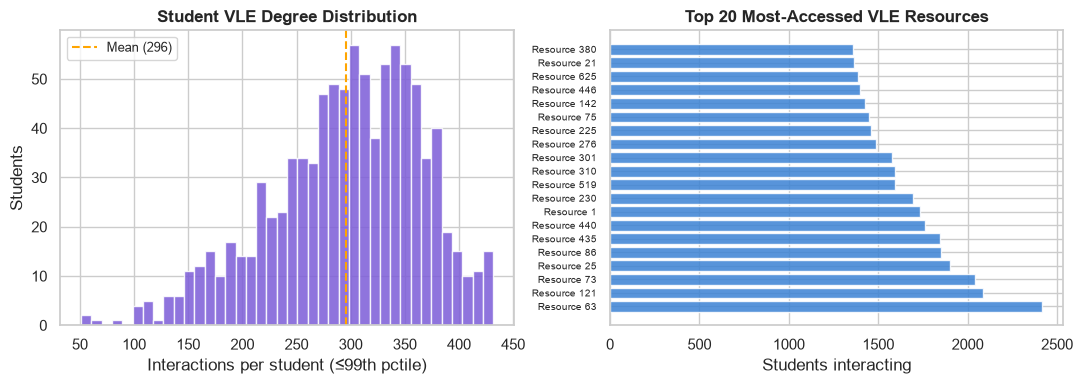

Students with ≥1 interaction : 940 / 4,280 (22.0%)
Mean interactions per student: 296.0
Median                        : 304
Max                           : 462


In [7]:
iw = edges["interacted_with"]
degree = iw.groupby("src")["dst"].count()   # student out-degree

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Histogram
ax = axes[0]
ax.hist(degree.clip(upper=degree.quantile(0.99)), bins=40, color=ACCENT, edgecolor="white", alpha=0.85)
ax.set_xlabel("Interactions per student (≤99th pctile)")
ax.set_ylabel("Students")
ax.set_title("Student VLE Degree Distribution", fontweight="bold")
ax.axvline(degree.mean(), color="orange", lw=1.5, linestyle="--",
           label=f"Mean ({degree.mean():.0f})")
ax.legend(fontsize=9)

# Resource popularity
ax = axes[1]
res_pop = iw.groupby("dst")["src"].count().sort_values(ascending=False).head(20)
ax.barh(range(len(res_pop)), res_pop.values, color=SUCCESS, alpha=0.85)
ax.set_yticks(range(len(res_pop)))
ax.set_yticklabels([f"Resource {i}" for i in res_pop.index], fontsize=7)
ax.set_xlabel("Students interacting")
ax.set_title("Top 20 Most-Accessed VLE Resources", fontweight="bold")

plt.tight_layout()
plt.show()

print(f"Students with ≥1 interaction : {(degree >= 1).sum():,} / {len(enrollments):,} ({(degree >= 1).sum()/len(enrollments):.1%})")
print(f"Mean interactions per student: {degree.mean():.1f}")
print(f"Median                        : {degree.median():.0f}")
print(f"Max                           : {degree.max():,}")


## 5. VLE Activity Over the 56-Day Window

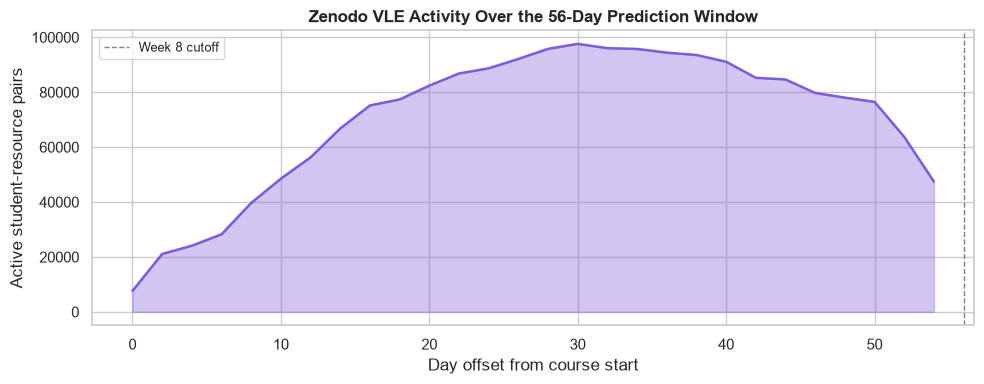

In [8]:
iw_time = iw.copy()
# first_day/last_day represent the range of activity for each student–resource edge
day_bins = list(range(0, 58, 2))
active_counts = []
for d in day_bins[:-1]:
    mask = (iw_time["first_day"] <= d) & (iw_time["last_day"] >= d)
    active_counts.append(mask.sum())

fig, ax = plt.subplots(figsize=(10, 4))
ax.fill_between(day_bins[:-1], active_counts, alpha=0.35, color=ACCENT)
ax.plot(day_bins[:-1], active_counts, color=ACCENT, lw=1.8)
ax.set_xlabel("Day offset from course start")
ax.set_ylabel("Active student-resource pairs")
ax.set_title("Zenodo VLE Activity Over the 56-Day Prediction Window", fontweight="bold")
ax.axvline(56, color="grey", lw=1.0, linestyle="--", label="Week 8 cutoff")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


## 6. Split Summary

### Random-Student Split (70 / 10 / 20)
Stratified by student: all enrollments of a student appear in exactly one partition.

### LCPO — Leave-Course-Presentation-Out (6 folds)
One fold per (course, year) combination. Measures generalisation to an unseen
course-presentation — the strictest evaluation protocol.


In [9]:
with open(SPLITS_DIR / "week08_splits_config.json") as f:
    split_cfg = json.load(f)

rs = split_cfg["random_student_split"]
print("=== Random-Student Split ===")
print(f"  Train : {rs['n_train']:,}  ({rs['n_train']/split_cfg['enrollment_count']:.1%})")
print(f"  Val   : {rs['n_val']:,}   ({rs['n_val']/split_cfg['enrollment_count']:.1%})")
print(f"  Test  : {rs['n_test']:,}  ({rs['n_test']/split_cfg['enrollment_count']:.1%})")

print()
folds = pd.read_csv(SPLITS_DIR / "week08_lcpo_folds.csv")
print("=== LCPO Folds ===")
for _, row in folds.iterrows():
    held_pres = str(int(row['held_out_presentation'])) if isinstance(row['held_out_presentation'], float) else row['held_out_presentation']
    print(f"  Fold {int(row['fold_idx']):02d}  {row['held_out_module']:25s} {held_pres}  "
          f"n_train={row['n_train']:,}  n_test={row['n_test']:,}")


=== Random-Student Split ===
  Train : 3,008  (70.3%)
  Val   : 421   (9.8%)
  Test  : 851  (19.9%)

=== LCPO Folds ===
  Fold 00  Accountancy               1819  n_train=3,528  n_test=752
  Fold 01  Accountancy               1920  n_train=3,575  n_test=705
  Fold 02  Accountancy               2021  n_train=3,557  n_test=723
  Fold 03  Global economics          1819  n_train=3,537  n_test=743
  Fold 04  Global economics          1920  n_train=3,599  n_test=681
  Fold 05  Global economics          2021  n_train=3,604  n_test=676


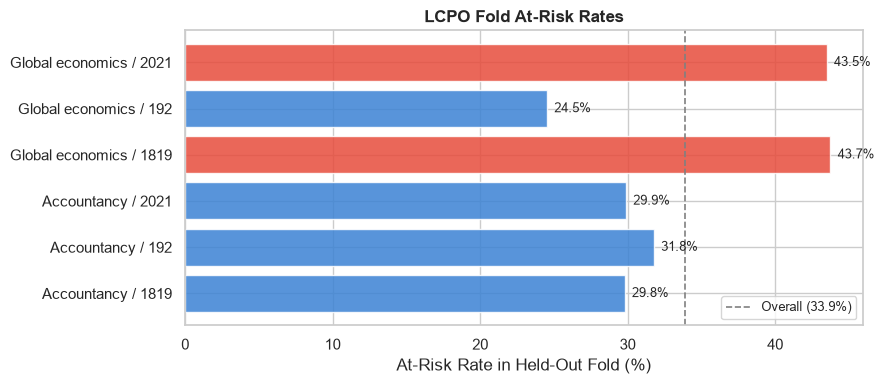

In [10]:
# Class balance per LCPO fold
fig, ax = plt.subplots(figsize=(9, 4))
fold_labels = folds["held_out_module"] + " / " + folds["held_out_presentation"].astype(str).str.rstrip('.0')
test_rates = []
for _, row in folds.iterrows():
    ho_pres = str(int(row['held_out_presentation'])) if isinstance(row['held_out_presentation'], float) else str(row['held_out_presentation'])
    mask = (enrollments["code_module"] == row["held_out_module"]) &            (enrollments["code_presentation"] == ho_pres)
    rate = enrollments[mask]["target"].mean()
    test_rates.append(rate)

colors = [ATRISK if r >= 0.338 else SUCCESS for r in test_rates]
bars = ax.barh(fold_labels, [r * 100 for r in test_rates], color=colors, alpha=0.85, edgecolor="white")
ax.axvline(enrollments["target"].mean() * 100, color="grey", lw=1.2, linestyle="--",
           label=f"Overall ({enrollments['target'].mean():.1%})")
ax.set_xlabel("At-Risk Rate in Held-Out Fold (%)")
ax.set_title("LCPO Fold At-Risk Rates", fontweight="bold")
ax.legend(fontsize=9)
for bar, rate in zip(bars, test_rates):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"{rate:.1%}", va="center", fontsize=9)
plt.tight_layout()
plt.show()


## 7. Heterogeneous Graph Schema

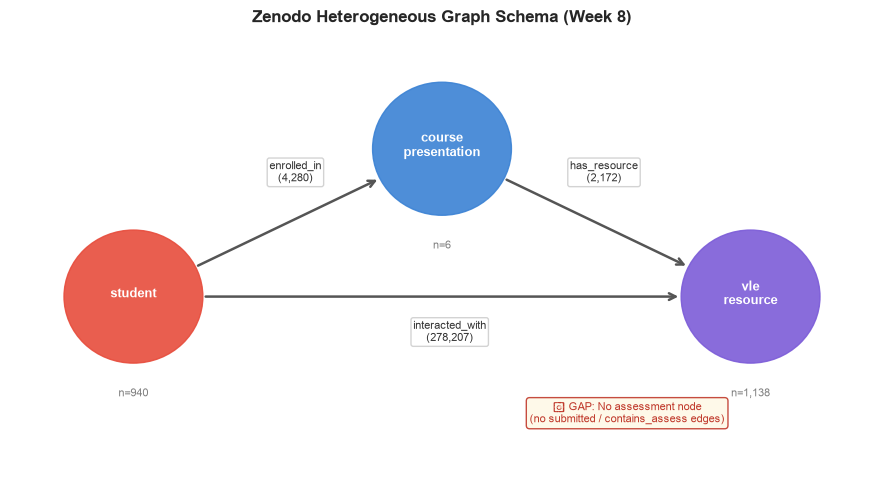

In [11]:
import networkx as nx
import matplotlib.patches as mpatches

# Build schema diagram
G = nx.DiGraph()
node_types = list(nodes.keys())
edge_type_pairs = {
    "enrolled_in":     ("student", "course_presentation"),
    "interacted_with": ("student", "vle_resource"),
    "has_resource":    ("course_presentation", "vle_resource"),
}

colors_map = {"student": ATRISK, "course_presentation": SUCCESS, "vle_resource": ACCENT}

fig, ax = plt.subplots(figsize=(9, 5))
pos = {"student": (0, 0), "course_presentation": (2, 1), "vle_resource": (4, 0)}

for ntype, (x, y) in pos.items():
    ax.add_patch(plt.Circle((x, y), 0.45, color=colors_map[ntype], zorder=3, alpha=0.9))
    count = f"n={len(nodes[ntype]):,}"
    ax.text(x, y + 0.02, ntype.replace("_", "\n"), ha="center", va="center",
            fontsize=9, fontweight="bold", color="white", zorder=4)
    ax.text(x, y - 0.62, count, ha="center", va="top", fontsize=8, color="grey")

edge_label_offset = {
    "enrolled_in":     (0.05, 0.28),
    "interacted_with": (0.05, -0.30),
    "has_resource":    (0.05, 0.28),
}
for etype, (src, dst) in edge_type_pairs.items():
    sx, sy = pos[src]; dx, dy = pos[dst]
    ax.annotate("", xy=(dx - 0.45*(dx-sx)/((dx-sx)**2+(dy-sy)**2)**0.5,
                         dy - 0.45*(dy-sy)/((dx-sx)**2+(dy-sy)**2)**0.5),
                xytext=(sx + 0.45*(dx-sx)/((dx-sx)**2+(dy-sy)**2)**0.5,
                        sy + 0.45*(dy-sy)/((dx-sx)**2+(dy-sy)**2)**0.5),
                arrowprops=dict(arrowstyle="->", lw=1.8, color="#555"),
                zorder=2)
    mx = (sx + dx) / 2 + edge_label_offset[etype][0]
    my = (sy + dy) / 2 + edge_label_offset[etype][1]
    n_edges = len(edges[etype])
    ax.text(mx, my, f"{etype}\n({n_edges:,})", ha="center", fontsize=8, color="#333",
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="#ccc", alpha=0.85))

# GAP annotation
ax.text(3.2, -0.85,
        "⚠ GAP: No assessment node\n(no submitted / contains_assess edges)",
        ha="center", fontsize=8, color="#c0392b",
        bbox=dict(boxstyle="round,pad=0.3", fc="#fef9e7", ec="#c0392b", alpha=0.9))

ax.set_xlim(-0.8, 4.8); ax.set_ylim(-1.2, 1.8)
ax.axis("off")
ax.set_title("Zenodo Heterogeneous Graph Schema (Week 8)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


## 8. Side-by-Side Comparison: Zenodo vs. OULAD

This table summarises the structural differences between the two datasets at the
Week 8 prediction window. The OULAD figures come from
`results/graph/artifacts/week08_*.parquet`.


In [12]:
OULAD_ART = PROJECT_ROOT / "results" / "graph" / "artifacts"

def count_parquet(path):
    if path.exists(): return len(pd.read_parquet(path))
    return "N/A"

oulad_nodes = {
    p.stem.replace("week08_nodes_", ""): count_parquet(p)
    for p in sorted(OULAD_ART.glob("week08_nodes_*.parquet"))
}
oulad_edges = {
    p.stem.replace("week08_edges_", ""): count_parquet(p)
    for p in sorted(OULAD_ART.glob("week08_edges_*.parquet"))
}
oulad_enroll = pd.read_parquet(OULAD_ART / "week08_enrollments.parquet") if (OULAD_ART / "week08_enrollments.parquet").exists() else None

comparison = pd.DataFrame([
    ("Enrollments",           f"{len(enrollments):,}",   f"{len(oulad_enroll):,}" if oulad_enroll is not None else "N/A"),
    ("At-risk rate",          f"{enrollments['target'].mean():.1%}", f"{oulad_enroll['target'].mean():.1%}" if oulad_enroll is not None else "N/A"),
    ("Courses",               "2", "7"),
    ("Academic years",        "3", "5 (2013–2014)"),
    ("Node: student",         f"{len(nodes['student']):,}", f"{oulad_nodes.get('student','N/A'):,}" if isinstance(oulad_nodes.get('student'), int) else str(oulad_nodes.get('student','N/A'))),
    ("Node: course_pres.",    f"{len(nodes['course_presentation']):,}", f"{oulad_nodes.get('course_presentation','N/A'):,}" if isinstance(oulad_nodes.get('course_presentation'), int) else str(oulad_nodes.get('course_presentation','N/A'))),
    ("Node: vle_resource",    f"{len(nodes['vle_resource']):,}", f"{oulad_nodes.get('vle_resource','N/A'):,}" if isinstance(oulad_nodes.get('vle_resource'), int) else str(oulad_nodes.get('vle_resource','N/A'))),
    ("Node: assessment",      "—  (GAP)", f"{oulad_nodes.get('assessment','N/A'):,}" if isinstance(oulad_nodes.get('assessment'), int) else str(oulad_nodes.get('assessment','N/A'))),
    ("Edge: enrolled_in",     f"{len(edges['enrolled_in']):,}", f"{oulad_edges.get('enrolled_in','N/A'):,}" if isinstance(oulad_edges.get('enrolled_in'), int) else str(oulad_edges.get('enrolled_in','N/A'))),
    ("Edge: interacted_with", f"{len(edges['interacted_with']):,}", f"{oulad_edges.get('interacted_with','N/A'):,}" if isinstance(oulad_edges.get('interacted_with'), int) else str(oulad_edges.get('interacted_with','N/A'))),
    ("Edge: has_resource",    f"{len(edges['has_resource']):,}", f"{oulad_edges.get('has_resource','N/A'):,}" if isinstance(oulad_edges.get('has_resource'), int) else str(oulad_edges.get('has_resource','N/A'))),
    ("Edge: submitted",       "—  (GAP)", f"{oulad_edges.get('submitted','N/A'):,}" if isinstance(oulad_edges.get('submitted'), int) else str(oulad_edges.get('submitted','N/A'))),
    ("Edge: contains_assess", "—  (GAP)", f"{oulad_edges.get('contains_assess','N/A'):,}" if isinstance(oulad_edges.get('contains_assess'), int) else str(oulad_edges.get('contains_assess','N/A'))),
    ("Student demographics",  "—  (GAP)", "✓ (11 features)"),
    ("LCPO folds",            "6", "22"),
    ("Prediction window",     "Week 8 only", "Weeks 2, 4, 6, 8"),
], columns=["Metric", "Zenodo", "OULAD"])

pd.set_option("display.max_colwidth", None)
display(comparison.style.set_properties(**{"text-align": "left"})
        .set_table_styles([{"selector": "th", "props": [("text-align", "left")]}]))


,Metric,Zenodo,OULAD
0,Enrollments,"4,280","32,593"
1,At-risk rate,33.9%,52.8%
2,Courses,2,7
3,Academic years,3,5 (2013–2014)
4,Node: student,940,"28,785"
5,Node: course_pres.,6,22
6,Node: vle_resource,"1,138","6,364"
7,Node: assessment,— (GAP),40
8,Edge: enrolled_in,"4,280","32,593"
9,Edge: interacted_with,"278,207","1,056,217"


---

## Summary

The Zenodo dataset is **7.6× smaller** than OULAD (4,280 vs 32,593 enrollments),
covers only 2 courses, and is missing 3 of OULAD's 5 edge types (assessment,
submission, demographics). These gaps are handled explicitly in
`src/zenodo_data.py` with `# GAP:` comments and documented in
[`docs/DESIGN_DECISIONS.md`](../docs/DESIGN_DECISIONS.md) §4.

All artefacts are reproducible by running:
```bash
python src/run_zenodo_pipeline.py  --skip-gnn
python src/run_zenodo_lgbm_only.py
python src/run_zenodo_pipeline.py  # full GNN run (~15 min)
```
